In [1]:
import pandas as pd

hpa = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_hpa.csv")  
print(hpa.shape)
print(hpa.columns.tolist())
hpa.head()

(24315372, 10)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'source', 'tpm', 'pTPM', 'nTPM', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,source,tpm,pTPM,nTPM,log2_tpm_plus1,is_expressed
0,ACH-001001,CVCL_2270,ENSG00000000003,TSPAN6,hpa,22.0,27.6,25.9,4.523562,True
1,ACH-000956,CVCL_1045,ENSG00000000003,TSPAN6,hpa,2.8,3.6,2.7,1.925999,True
2,ACH-000948,CVCL_1046,ENSG00000000003,TSPAN6,hpa,6.2,7.5,7.5,2.847997,True
3,ACH-000011,CVCL_7935,ENSG00000000003,TSPAN6,hpa,14.2,18.7,25.4,3.925999,True
4,ACH-000026,CVCL_7937,ENSG00000000003,TSPAN6,hpa,13.0,17.1,18.5,3.807355,True


In [4]:
print(hpa["source"].unique())

['hpa']


In [2]:
geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")  
print(geo.shape)
print(geo.columns.tolist())
geo.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_2144\1781234455.py:1: DtypeWarning: Columns (0,1) have mixed types. Specify dtype option on import or set low_memory=False.
  geo = pd.read_csv("../../data/AZ_harmonized_data/geo.csv")


(65059038, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'GSM_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,GSM_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-000558,CVCL_0131,ENSG00000000003,GSM101610,geo,33.615700,5.113355,True
1,ACH-000558,CVCL_0131,ENSG00000000005,GSM101610,geo,40.925682,5.389762,True
2,ACH-000558,CVCL_0131,ENSG00000000419,GSM101610,geo,2182.281250,11.092282,True
3,ACH-000558,CVCL_0131,ENSG00000000457,GSM101610,geo,58.934814,5.905322,True
4,ACH-000558,CVCL_0131,ENSG00000000460,GSM101610,geo,136.418900,7.102437,True


In [5]:
# does one cell line have multiple GSM samples?
geo.groupby("ACH_ID")["GSM_ID"].nunique().sort_values(ascending=False).head()

ACH_ID
ACH-002875    108
ACH-001188     67
ACH-000019     49
ACH-000768     41
ACH-000681     31
Name: GSM_ID, dtype: int64

In [3]:
depmap = pd.read_csv("../../data/AZ_harmonized_data/fact_expression_depmap.csv")
print(depmap.shape)
print(depmap.columns.tolist())
depmap.head()

(80039310, 9)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'hugo_symbol', 'PR_ID', 'source', 'tpm', 'log2_tpm_plus1', 'is_expressed']


,ACH_ID,CVCL_ID,ensembl_id,hugo_symbol,PR_ID,source,tpm,log2_tpm_plus1,is_expressed
0,ACH-001113,CVCL_5480,ENSG00000000005,TNMD,PR-AdBjpG,depmap,0.0,0.000000,False
1,ACH-001289,CVCL_RS25,ENSG00000000005,TNMD,PR-I2AzwG,depmap,0.5,0.584963,False
2,ACH-001339,CVCL_2408,ENSG00000000005,TNMD,PR-5ekAAC,depmap,0.0,0.000000,False
3,ACH-001538,CVCL_M261,ENSG00000000005,TNMD,PR-I21681,depmap,0.0,0.000000,False
4,ACH-000242,CVCL_0036,ENSG00000000005,TNMD,PR-i9DRP1,depmap,0.0,0.000000,False


In [6]:
print("depmap:", depmap.shape)
print("hpa:", hpa.shape)
print("geo:", geo.shape)

depmap: (80039310, 9)
hpa: (24315372, 10)
geo: (65059038, 8)


In [13]:
target = "ENSG00000146648"   # EGFR

# 1. pull the gene's rows from each source (only the columns we need)
cols = ["ACH_ID", "source", "log2_tpm_plus1"]
frames = [
    depmap[depmap["ensembl_id"] == target][cols],
    hpa[hpa["ensembl_id"] == target][cols],
    geo[geo["ensembl_id"] == target][cols],
]
allg = pd.concat(frames)

# 2. GEO can have multiple samples per cell line average per (cell line, source) first
allg = allg.groupby(["ACH_ID", "source"])["log2_tpm_plus1"].mean().reset_index()

# 3. percentile-rank cell lines WITHIN each source
allg["percentile"] = allg.groupby("source")["log2_tpm_plus1"].rank(pct=True) * 100

import numpy as np

# 4. combine: average percentile per cell line, count sources, and get standard deviation
combined = (allg.groupby("ACH_ID")
                .agg(rna_percentile=("percentile", "mean"),
                     n_sources=("source", "nunique"),
                     source_std=("percentile", "std")) # Calculate standard deviation across sources
                .reset_index())

# If a cell line only has 1 source, standard deviation is NaN. Fill it with 0.
combined["source_std"] = combined["source_std"].fillna(0)

# Calculate the final confidence score
combined["confidence_score"] = 1 / (1 + combined["source_std"])

# Sort by RNA percentile first, then use confidence score as a tie-breaker
combined = combined.sort_values(by=["rna_percentile", "confidence_score"], ascending=[False, False])

print(combined.shape)
combined.head(10)

print(combined.shape)
combined.head(10)

(1581, 5)
(1581, 5)


,ACH_ID,rna_percentile,n_sources,source_std,confidence_score
1235,ACH-001523,100.000000,1,0.000000,1.000000
737,ACH-000741,99.875696,2,0.080173,0.925777
633,ACH-000637,99.819525,2,0.127248,0.887117
1186,ACH-001411,99.797160,1,0.000000,1.000000
1397,ACH-001864,99.661934,1,0.000000,1.000000
10,ACH-000012,99.524868,3,0.475628,0.677678
1536,ACH-002680,99.459094,1,0.000000,1.000000
107,ACH-000109,99.408441,3,0.223103,0.817593
1306,ACH-001649,99.391481,1,0.000000,1.000000
865,ACH-000869,99.337586,3,0.338249,0.747245


In [9]:
# load the cell line dictionary
dim = pd.read_csv("../../data/AZ_harmonized_data/dim_cell_lines.csv")
print(dim.columns.tolist())   # check the name column

['ach_id', 'cvcl_id', 'cell_line_name', 'ccle_name', 'primary_disease', 'Subtype', 'lineage', 'lineage_subtype', 'sex', 'age', 'primary_or_metastasis', 'sample_collection_site', 'growth_pattern', 'COSMICID', 'Sanger_Model_ID', 'source', 'metadata_source', 'profile_ids', 'n_profiles', 'has_real_name', 'has_full_metadata']


In [14]:
# merge names onto the ranking
named = combined.merge(
    dim[["ach_id", "cell_line_name", "primary_disease", "lineage"]],
    left_on="ACH_ID", right_on="ach_id", how="left"
)
named[["ACH_ID", "cell_line_name", "primary_disease", "lineage", "rna_percentile", "n_sources", "confidence_score"]].head(10)

,ACH_ID,cell_line_name,primary_disease,lineage,rna_percentile,n_sources,confidence_score
0,ACH-001523,HSC1,Skin Cancer,skin,100.000000,1,1.000000
1,ACH-000741,UBLC1,Bladder Cancer,urinary_tract,99.875696,2,0.925777
2,ACH-000637,KYSE520,Esophageal Cancer,esophagus,99.819525,2,0.887117
3,ACH-001411,UMUC5,Bladder Cancer,urinary_tract,99.797160,1,1.000000
4,ACH-001864,YSCCC,Bile Duct Cancer,bile_duct,99.661934,1,1.000000
5,ACH-000012,HCC827,Lung Cancer,lung,99.524868,3,0.677678
6,ACH-002680,170MGBA,Brain Cancer,central_nervous_system,99.459094,1,1.000000
7,ACH-000109,NCIH3255,Lung Cancer,lung,99.408441,3,0.817593
8,ACH-001649,SHMAC5,Prostate Cancer,prostate,99.391481,1,1.000000
9,ACH-000869,NCIH1568,Lung Cancer,lung,99.337586,3,0.747245


In [16]:
# Load the team's harmonized proteomics data instead of the raw file
fact_prot = pd.read_csv("../../data/AZ_harmonized_data/fact_proteomics.csv")

print(fact_prot.shape)
print(fact_prot.columns.tolist())
fact_prot.head(10)

(4709250, 8)
['ACH_ID', 'CVCL_ID', 'ensembl_id', 'uniprot_id', 'hugo_symbol', 'protein_intensity', 'is_detected', 'z_score']


,ACH_ID,CVCL_ID,ensembl_id,uniprot_id,hugo_symbol,protein_intensity,is_detected,z_score
0,ACH-000849,CVCL_0419,ENSG00000163694,A0AV96,RBM47,0.358567,True,0.263468
1,ACH-000441,CVCL_1692,ENSG00000163694,A0AV96,RBM47,-1.112410,True,-0.808447
2,ACH-000248,CVCL_1074,ENSG00000163694,A0AV96,RBM47,0.855575,True,0.625642
3,ACH-000684,CVCL_2983,ENSG00000163694,A0AV96,RBM47,0.061377,True,0.046903
4,ACH-000856,CVCL_1110,ENSG00000163694,A0AV96,RBM47,0.284258,True,0.209318
5,ACH-000348,CVCL_1666,ENSG00000163694,A0AV96,RBM47,-0.485070,True,-0.351298
6,ACH-000062,CVCL_1655,ENSG00000163694,A0AV96,RBM47,0.092390,True,0.069502
7,ACH-000650,CVCL_2075,ENSG00000163694,A0AV96,RBM47,-0.824035,True,-0.598306
8,ACH-000484,CVCL_1790,ENSG00000163694,A0AV96,RBM47,0.926286,True,0.677170
9,ACH-000625,CVCL_0326,ENSG00000163694,A0AV96,RBM47,1.323508,True,0.966630


In [18]:
# Filter the proteomics data for target gene
prot_expr = fact_prot[fact_prot["ensembl_id"] == target][["ACH_ID", "protein_intensity"]].dropna().copy()

if not prot_expr.empty:
    # Calculate percentile rank for proteomics
    prot_expr["protein_percentile"] = prot_expr["protein_intensity"].rank(pct=True) * 100
    
    # Merge with combined RNA table
    final_ranking = pd.merge(combined, prot_expr[["ACH_ID", "protein_percentile"]], on="ACH_ID", how="left")
    
    # Calculate a composite omics score 
    # (Averages RNA and Protein percentiles; if protein is NaN, it ignores it and uses just the RNA percentile)
    final_ranking["composite_percentile"] = final_ranking[["rna_percentile", "protein_percentile"]].mean(axis=1)
    
    # Re-sort by the final composite score and then confidence
    final_ranking = final_ranking.sort_values(by=["composite_percentile", "confidence_score"], ascending=[False, False])
    
    # Merge names back on so it's readable
    named_final = final_ranking.merge(
        dim[["ach_id", "cell_line_name", "primary_disease", "lineage"]],
        left_on="ACH_ID", right_on="ach_id", how="left"
    ).drop(columns=["ach_id"])
    
    print("Merged with Proteomics! Final shape:", named_final.shape)
    display(named_final[["ACH_ID", "cell_line_name", "primary_disease", "rna_percentile", "protein_percentile", "composite_percentile", "n_sources", "confidence_score"]].head(10))
    
else:
    print(f"No proteomics data found for target {target}.")

Merged with Proteomics! Final shape: (1581, 10)


,ACH_ID,cell_line_name,primary_disease,rna_percentile,protein_percentile,composite_percentile,n_sources,confidence_score
0,ACH-001523,HSC1,Skin Cancer,100.000000,NaN,100.000000,1,1.000000
1,ACH-000741,UBLC1,Bladder Cancer,99.875696,100.0,99.937848,2,0.925777
2,ACH-000637,KYSE520,Esophageal Cancer,99.819525,NaN,99.819525,2,0.887117
3,ACH-001411,UMUC5,Bladder Cancer,99.797160,NaN,99.797160,1,1.000000
4,ACH-001864,YSCCC,Bile Duct Cancer,99.661934,NaN,99.661934,1,1.000000
5,ACH-002680,170MGBA,Brain Cancer,99.459094,NaN,99.459094,1,1.000000
6,ACH-001649,SHMAC5,Prostate Cancer,99.391481,NaN,99.391481,1,1.000000
7,ACH-000472,HSC2,Head and Neck Cancer,99.258259,NaN,99.258259,3,0.659115
8,ACH-001328,A431,Skin Cancer,99.199164,NaN,99.199164,3,0.505135
9,ACH-000170,PRECLH,Non-Cancerous,99.141832,NaN,99.141832,2,0.937912


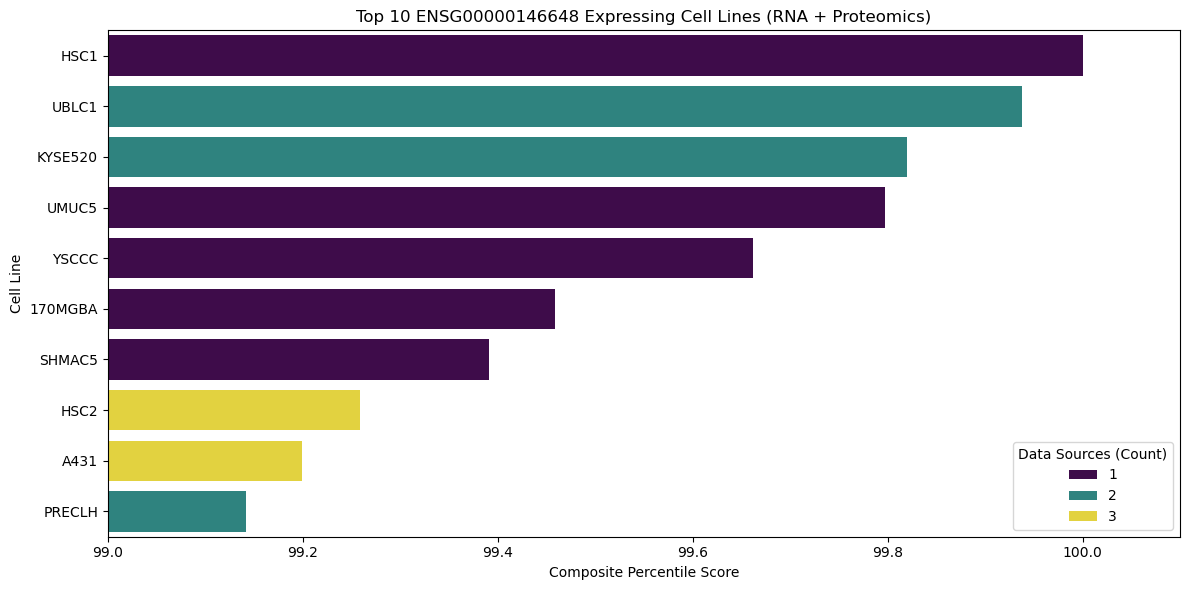

Saved ranking to ../../processed/ENSG00000146648_composite_baseline.parquet


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

#Take the top 10 from finalized table
top_10 = named_final.head(10)

#Set up the visualization
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top_10, 
    x="composite_percentile", 
    y="cell_line_name", 
    hue="n_sources", 
    palette="viridis",
    dodge=False
)

plt.title(f"Top 10 {target} Expressing Cell Lines (RNA + Proteomics)")
plt.xlabel("Composite Percentile Score")
plt.ylabel("Cell Line")
plt.xlim(99.0, 100.1) #Zoom in to see the minute differences at the top
plt.legend(title="Data Sources (Count)", loc="lower right")
plt.tight_layout()
plt.show()

#Save the final output to local machine
output_filename = f"../../processed/{target}_composite_baseline.parquet"
named_final.to_parquet(output_filename)
print(f"Saved ranking to {output_filename}")